# Regression Models on Student Performance & Ice Cream Sales
 
 This notebook demonstrates how to build and evaluate regression models using **scikit-learn**:
 - **Part A**: Linear Regression on Student Performance dataset
 - **Part B**: Polynomial Regression on Ice Cream Sales dataset

 We will use appropriate evaluation metrics for each model:
 - Student Performance → MAE (Mean Absolute Error) + R²
 - Ice Cream Sales → RMSE (Root Mean Squared Error) + R²

In [3]:
import pandas as pd  # For data handling
import numpy as np  # For numerical operations
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test
from sklearn.linear_model import LinearRegression  # For linear regression model
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder  # For polynomial regression & encoding categorical variables
from sklearn.pipeline import make_pipeline  # To chain preprocessing + model together
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # For regression evaluation metrics
import matplotlib.pyplot as plt  # For plotting results

## Part A: Linear Regression on Student Performance
 The goal is to predict a student's **Performance Index** based on study-related features.
 We will evaluate the model using:
 - **MAE**: Average prediction error in exam points.
 - **R²**: Variance explained by the model.

In [16]:
# YOUR CODE HERE

# Load dataset into a pandas DataFrame
student_df = pd.read_csv('Student_Performance.csv')

# Encode categorical column 'Extracurricular Activities' into numeric values (Yes/No → 1/0)
#le =
student_df["Extracurricular Activities"] = student_df["Extracurricular Activities"].map({'Yes':1,'No':0})

# Separate features (X) and target (y)
X_student =  student_df.drop('Performance Index',axis= 1)
y_student =  student_df['Performance Index']


# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_student,
    y_student,
    test_size= 0.2,
    random_state=42
)

# Initialize linear regression model
lin_reg = LinearRegression()

# Train the model using training data
lin_reg.fit(X_train,y_train)
# Make predictions on test data
y_pred = lin_reg.predict(X_test)

# Evaluate model with MAE (average error in exam points)
mae_student = mean_absolute_error(y_test,y_pred)

# Evaluate model with R^2 (variance explained)
r2_student = r2_score(y_test, y_pred) 

# Print evaluation results
print("Student Performance Model:")
print("MAE (average error in exam points):", mae_student)
print("R^2 (variance explained):", r2_student)


Student Performance Model:
MAE (average error in exam points): 1.6111213463123042
R^2 (variance explained): 0.9889832909573145


## Part B: Polynomial Regression on Ice Cream Sales
 The goal is to predict **Ice Cream Sales** from **Temperature (°C)**.
 Polynomial regression is used since the relationship is nonlinear.
 We evaluate using:
 - **RMSE**: Typical prediction error, penalizing large mistakes.
 - **R²**: Variance explained by the model.

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load dataset into a pandas DataFrame
icecream_df = pd.read_csv('Ice_cream selling data.csv') 

# Define feature (temperature) and target (ice cream sales)
X_ice = icecream_df[['Temperature (°C)']]   # Double brackets keep it as DataFrame
y_ice = icecream_df['Ice Cream Sales (units)']

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_ice, y_ice, test_size=0.2, random_state=42
)

# Create a polynomial regression model pipeline (degree=2)
# Step 1: Transform input into polynomial features
# Step 2: Apply linear regression on the transformed features
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Train polynomial regression model on training data
poly_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_poly = poly_model.predict(X_test)

# Evaluate model with RMSE (penalizes large errors)
rmse_ice = np.sqrt(mean_squared_error(y_test, y_pred_poly))

# Evaluate model with R^2 (variance explained)
r2_ice = r2_score(y_test, y_pred_poly)

# Print evaluation results
print("\nIce Cream Sales Model (Polynomial Regression):")
print("RMSE (typical error size, penalizing big mistakes):", rmse_ice)
print("R^2 (variance explained):", r2_ice)


Ice Cream Sales Model (Polynomial Regression):
RMSE (typical error size, penalizing big mistakes): 3.857304297171986
R^2 (variance explained): 0.8430551371938841


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


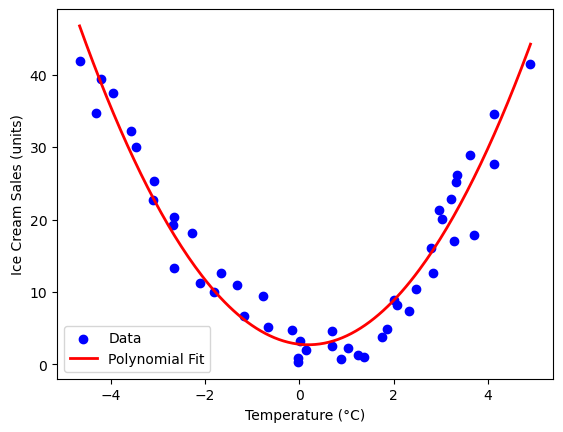

In [21]:
# ### Visualization
# Let's visualize the polynomial regression curve along with the actual data points.
plt.scatter(X_ice, y_ice, color="blue", label="Data")  # Scatter plot of actual data
x_range = np.linspace(X_ice.min(), X_ice.max(), 200).reshape(-1,1)  # Generate smooth range of X values
y_range = poly_model.predict(x_range)  # Predict sales for smooth range
plt.plot(x_range, y_range, color="red", linewidth=2, label="Polynomial Fit")  # Plot polynomial curve
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.legend()
plt.show()